### STEP1: LOAD THE SAVED PICKLE FILE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import time

In [4]:
df_la_daily= pd.read_csv("../data/la_daily_2017_2023.csv",parse_dates=["date"])
df_la_daily.set_index("date",inplace=True)
df_la_daily = df_la_daily.sort_index()
df_la_daily = df_la_daily.asfreq('D')
df_la_daily.head()

,pm25_cf_1,humidity,temperature,pressure
date,,,,
2017-01-01,25.714433,54.929449,59.433115,59.433218
2017-01-02,7.568054,53.618319,61.723596,61.726110
2017-01-03,18.169412,52.460524,62.956328,62.954285
2017-01-04,21.875172,51.506422,63.944057,63.943135
2017-01-05,16.650620,65.335559,65.901941,65.899936


#### RESAMPLE TO MONTHLY FREQUENCY

In [5]:
#Resample to monthly frequency
df_la_monthly = df_la_daily[['pm25_cf_1']].resample('ME').mean()
df_la_monthly.head()

,pm25_cf_1
date,
2017-01-31,10.512280
2017-02-28,10.950743
2017-03-31,14.132510
2017-04-30,8.459234
2017-05-31,10.066669


### STEP2: Apply ADF Stationarity Test

In [6]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_la_monthly['pm25_cf_1'], regression='c')
print(result[1])  # p-value
if result[1] < 0.05:
    print(f"\n  RESULT: STATIONARY (p-value = {result[1]:.6f} < 0.05)")
    print(f"    We REJECT the null hypothesis of a unit root.")
else:
    print(f"\n  RESULT: NON-STATIONARY (p-value = {result[1]:.6f} >= 0.05)")
    print(f"    We FAIL TO REJECT the null hypothesis of a unit root.")


2.498381759290181e-05

  RESULT: STATIONARY (p-value = 0.000025 < 0.05)
    We REJECT the null hypothesis of a unit root.


The data is stationary and does not need differenciating. (d=0)

### STEP3: PLOT ACF/PACF 

<Figure size 1000x500 with 0 Axes>

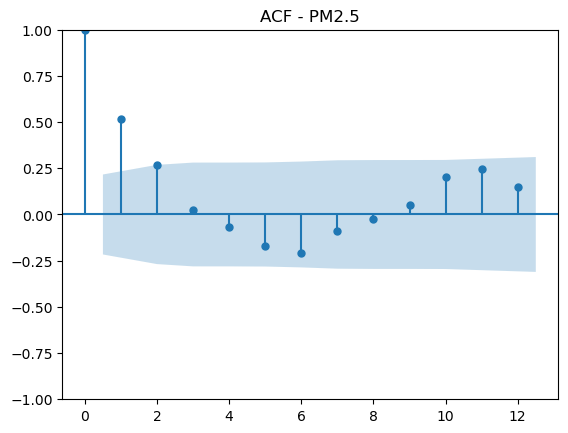

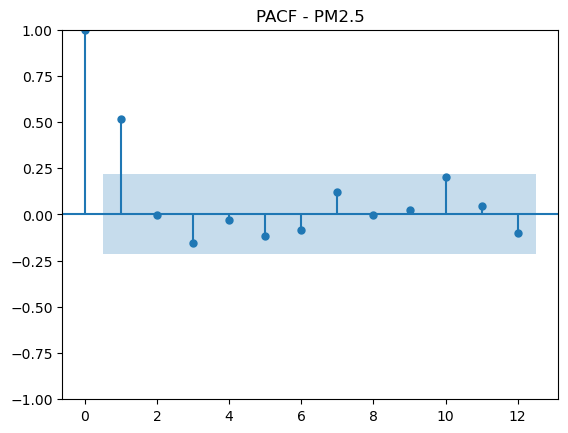

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df_la_monthly['pm25_cf_1']

plt.figure(figsize=(10,5))
plot_acf(series, lags=12)
plt.title("ACF - PM2.5")
plt.show()

plot_pacf(series, lags=12)
plt.title("PACF - PM2.5")
plt.show()

ACF shows strong positive spike at lag 1 and then gradual decay, no sharp cutoff  and suggests AR behaviour

PACF: Very strong spike at lag 1 and mostly inside confidence band.

order = (1,0,0)    ?
seasonal_order = (1,0,0,12)

In [9]:
df_train = df_la_monthly.loc['2017-01-01':'2021-12-31', 'pm25_cf_1']
df_test = df_la_monthly.loc['2022-01-01':'2022-12-31', 'pm25_cf_1']

print(df_train.shape)
print(df_test.shape)
print(df_train.head())
print(df_test.head())

(60,)
(12,)
date
2017-01-31    10.512280
2017-02-28    10.950743
2017-03-31    14.132510
2017-04-30     8.459234
2017-05-31    10.066669
Freq: ME, Name: pm25_cf_1, dtype: float64
date
2022-01-31    13.190218
2022-02-28     7.895480
2022-03-31     7.649690
2022-04-30     8.585666
2022-05-31    11.000223
Freq: ME, Name: pm25_cf_1, dtype: float64


### FIT SARIMAX

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = df_train.dropna()


model = SARIMAX(
    train,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

start_time=time.time()

results = model.fit()

end_time=time.time()

print(f"Model running time: {end_time - start_time:.2f} seconds")
print(results.summary())

Model running time: 0.03 seconds
                                     SARIMAX Results                                      
Dep. Variable:                          pm25_cf_1   No. Observations:                   60
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -144.781
Date:                            Wed, 11 Mar 2026   AIC                            295.562
Time:                                    21:32:02   BIC                            301.112
Sample:                                01-31-2017   HQIC                           297.651
                                     - 12-31-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9340      0.060     15.518      0.000       0.816       1.052
ar

Looking at the results: Each month's PM2.5 value is about 93% determined by the previous month's value
ar.S.L12 = -0.016 suggests that the seasonality component adds nothing to the model.


Manual SARIMAX Performance (Test Set) 
RMSE: 3.95
MAE: 2.96
MAPE: 32.04%


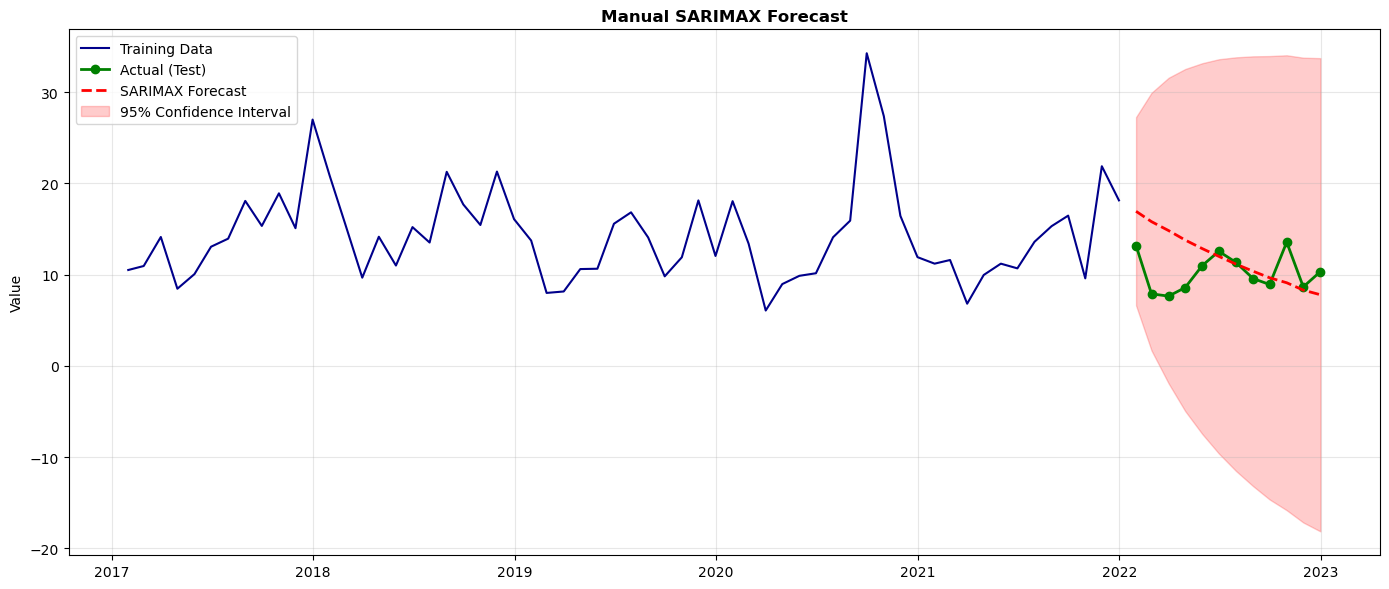

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Forecast on test set
forecast_manual = results.get_forecast(steps=len(df_test))
forecast_mean = forecast_manual.predicted_mean
forecast_ci = forecast_manual.conf_int()
    
# Evaluate
rmse = np.sqrt(mean_squared_error(df_test, forecast_mean))
mae = mean_absolute_error(df_test, forecast_mean)
mape = np.mean(np.abs((df_test - forecast_mean) / df_test)) * 100
    
print(f"\nManual SARIMAX Performance (Test Set) ")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
    
# Visualize
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train, label='Training Data', color='darkblue')
plt.plot(df_test.index, df_test, label='Actual (Test)', color='green', linewidth=2, marker='o')
plt.plot(df_test.index, forecast_mean, label='SARIMAX Forecast', color='red', linestyle='--', linewidth=2)
plt.fill_between(df_test.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                     color='red', alpha=0.2, label='95% Confidence Interval')
plt.title(f'Manual SARIMAX Forecast', fontweight='bold', fontsize=12)
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Average PM2.5 level in 2022
print(df_test.mean())

10.274455940092722


### Naive Baseline

In [13]:
naive_pred = df_test.shift(1)
naive_mae = mean_absolute_error(df_test[1:], naive_pred[1:])
print("Naive MAE:", naive_mae)

Naive MAE: 2.3006436342502976


The naive method is actually beating the SARIMAX model on the test set.

### SARIMAX WITH WEEKLY SEASONALITY

In [16]:
df_train = df_la_daily.loc['2017-01-01':'2021-12-31', 'pm25_cf_1']
df_test = df_la_daily.loc['2022-01-01':'2022-12-31', 'pm25_cf_1']

print(df_train.shape)
print(df_test.shape)
print(df_train.head())
print(df_test.head())

(1826,)
(365,)
date
2017-01-01    25.714433
2017-01-02     7.568054
2017-01-03    18.169412
2017-01-04    21.875172
2017-01-05    16.650620
Freq: D, Name: pm25_cf_1, dtype: float64
date
2022-01-01    13.474831
2022-01-02     6.652535
2022-01-03     7.473614
2022-01-04    14.154928
2022-01-05    21.662082
Freq: D, Name: pm25_cf_1, dtype: float64


In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = df_train.dropna()


model = SARIMAX(
    train,
    order=(1,0,0),
    seasonal_order=(1,0,0,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

start_time=time.time()

results = model.fit()

end_time=time.time()

print(f"Model running time: {end_time - start_time:.2f} seconds")
print(results.summary())

Model running time: 0.14 seconds
                                     SARIMAX Results                                     
Dep. Variable:                         pm25_cf_1   No. Observations:                 1826
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 7)   Log Likelihood               -6188.537
Date:                           Wed, 11 Mar 2026   AIC                          12383.073
Time:                                   21:41:42   BIC                          12399.590
Sample:                               01-01-2017   HQIC                         12389.167
                                    - 12-31-2021                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9017      0.006    161.541      0.000       0.891       0.913
ar.S.L7   


Manual SARIMAX Performance (Test Set) 
RMSE: 11.52
MAE: 10.07
MAPE: 97.57%


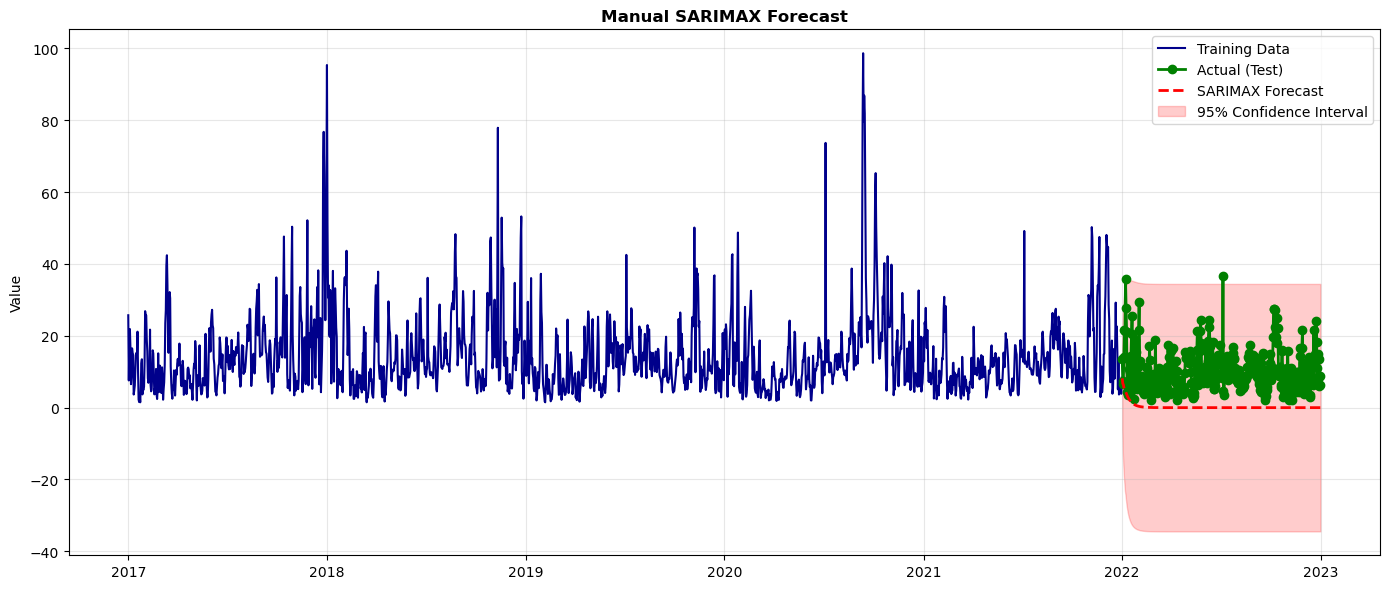

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Forecast on test set
forecast_manual = results.get_forecast(steps=len(df_test))
forecast_mean = forecast_manual.predicted_mean
forecast_ci = forecast_manual.conf_int()
    
# Evaluate
rmse = np.sqrt(mean_squared_error(df_test, forecast_mean))
mae = mean_absolute_error(df_test, forecast_mean)
mape = np.mean(np.abs((df_test - forecast_mean) / df_test)) * 100
    
print(f"\nManual SARIMAX Performance (Test Set) ")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
    
# Visualize
plt.figure(figsize=(14, 6))
plt.plot(df_train.index, df_train, label='Training Data', color='darkblue')
plt.plot(df_test.index, df_test, label='Actual (Test)', color='green', linewidth=2, marker='o')
plt.plot(df_test.index, forecast_mean, label='SARIMAX Forecast', color='red', linestyle='--', linewidth=2)
plt.fill_between(df_test.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                     color='red', alpha=0.2, label='95% Confidence Interval')
plt.title(f'Manual SARIMAX Forecast', fontweight='bold', fontsize=12)
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ADDING EXOGENOUS VARIABLES TO SARIMAX

In [20]:
df_train = df_la_daily.loc['2017-01-01':'2021-12-31']
df_test = df_la_daily.loc['2022-01-01':'2022-12-31']

exog_vars = ['temperature', 'humidity']
train = df_train.dropna()
exog_train = train[exog_vars]

model = SARIMAX(
    train['pm25_cf_1'],      
    exog=exog_train,        
    order=(1, 0, 0),
    seasonal_order=(1, 0, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

start_time = time.time()
results = model.fit(disp=False)
end_time = time.time()

print(f"Model running time: {end_time - start_time:.2f} seconds")
print(results.summary())

Model running time: 0.27 seconds
                                     SARIMAX Results                                     
Dep. Variable:                         pm25_cf_1   No. Observations:                 1826
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 7)   Log Likelihood               -6031.890
Date:                           Wed, 11 Mar 2026   AIC                          12073.781
Time:                                   21:48:34   BIC                          12101.308
Sample:                               01-01-2017   HQIC                         12083.937
                                    - 12-31-2021                                         
Covariance Type:                             opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temperature    -0.0035      0.020     -0.170      0.865      -0.043       0.036
humidit

In [21]:
exog_test = df_test[exog_vars].dropna()

predictions = results.forecast(steps=len(df_test), exog=exog_test)

In [23]:
mae = mean_absolute_error(df_test['pm25_cf_1'], predictions)
rmse = np.sqrt(mean_squared_error(df_test['pm25_cf_1'], predictions))
mape = np.mean(np.abs((df_test['pm25_cf_1'] - predictions) / df_test['pm25_cf_1'])) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  4.93
RMSE: 6.16
MAPE: 75.91%


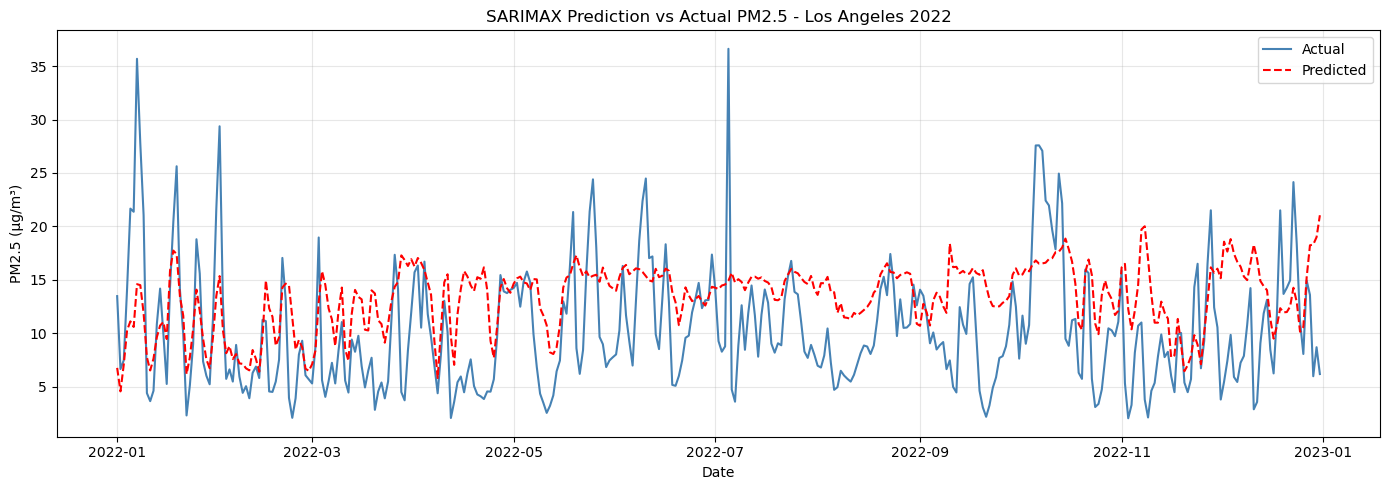

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(df_test.index, df_test['pm25_cf_1'], label='Actual', color='steelblue')
plt.plot(df_test.index, predictions, label='Predicted', color='red', linestyle='--')
plt.title('SARIMAX Prediction vs Actual PM2.5 - Los Angeles 2022')
plt.ylabel('PM2.5 (μg/m³)')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()